# Normalization for feature scaling 

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns


In [31]:
df = pd.read_csv("./Wine.csv",usecols=[0,1,2])
df

,Class,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Malic acid'>

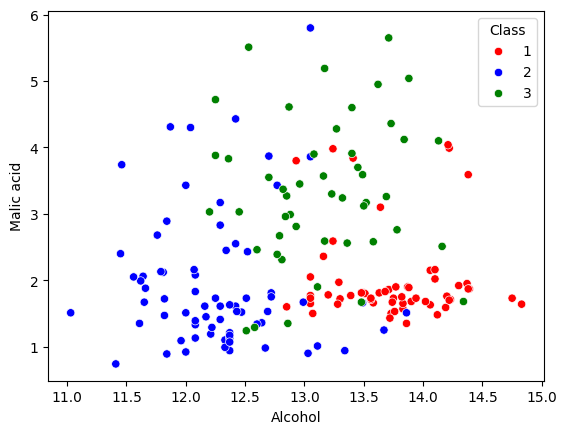

In [32]:
color_dict = {1:'red',2:'blue',3:'green'}

sns.scatterplot(
    data=df,
    x="Alcohol",
    y="Malic acid",
    hue="Class",
    palette=color_dict
)

In [33]:
#step 1 :- Split it 
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test =train_test_split(
    df.drop("Class",axis=1),df["Class"],test_size=0.2,random_state=0
)

In [34]:
 #step 2:- MinMaxScaler function 
from sklearn.preprocessing import MinMaxScaler
scaler =MinMaxScaler()
scaler.fit(X_train)
X_train_scaled=scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
#Scikit learn classes transforms the data into numpy when used , so we got to convert them into the dataframes again


In [35]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [36]:
X_train_scaled

,Alcohol,Malic acid
0,0.715054,0.513238
1,0.446237,0.160896
2,0.158602,0.254582
3,0.637097,0.645621
4,0.663978,0.217923
...,...,...
137,0.212366,0.199593
138,0.360215,0.087576
139,0.373656,0.177189
140,0.771505,0.191446


In [37]:
np.round(X_train.describe().round(2))

,Alcohol,Malic acid
count,142.0,142.0
mean,13.0,2.0
std,1.0,1.0
min,11.0,1.0
25%,12.0,2.0
50%,13.0,2.0
75%,14.0,3.0
max,15.0,6.0


In [39]:
np.round(X_train_scaled.describe(),2)

,Alcohol,Malic acid
count,142.00,142.00
mean,0.53,0.33
std,0.22,0.23
min,0.00,0.00
25%,0.35,0.18
50%,0.54,0.24
75%,0.70,0.51
max,1.00,1.00


<Axes: title={'center': 'After scaling the values'}, xlabel='Alcohol', ylabel='Density'>

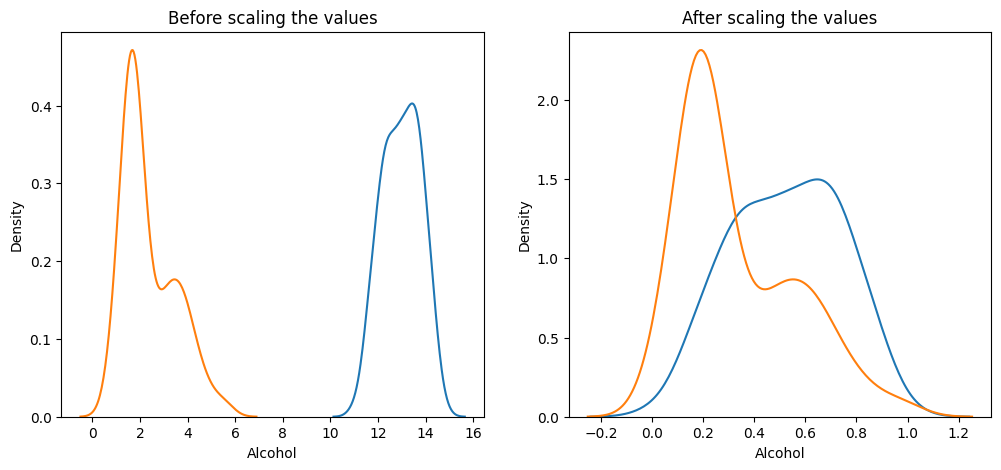

In [40]:
fig , (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
#before scaling
ax1.set_title("Before scaling the values")
sns.kdeplot(X_train["Alcohol"],ax=ax1)
sns.kdeplot(X_train["Malic acid"],ax=ax1)

#after scaling
ax2.set_title("After scaling the values")
sns.kdeplot(X_train_scaled["Alcohol"],ax=ax2) 
sns.kdeplot(X_train_scaled["Malic acid"],ax=ax2) 


### Both came in same range and thats why they are at the same scale